## Model Building


Original Image -> Resize 224×224 -> RGB Conversion -> Face Detection -> Face Crop -> Normalization -> Augmentation -> Model

### data loading

In [41]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


In [42]:
# Load cleaned dataset
df = pd.read_csv("dataset_clean.csv")

In [43]:
print("Dataset shape:", df.shape)

Dataset shape: (5557, 5)


In [44]:
df.head()

,image_id,image_url,label,gender,age_group
0,1,https://images.unsplash.com/photo-172422561835...,REAL,Female,18-25
1,2,https://images.unsplash.com/photo-172422561873...,REAL,Male,50+
2,3,https://images.unsplash.com/photo-172422561834...,REAL,Female,36-50
3,4,https://images.unsplash.com/photo-172422561855...,REAL,Female,26-35
4,5,https://images.unsplash.com/photo-172422561823...,REAL,Male,36-50


In [45]:
# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [46]:
# Check image files
df["image_path"] = df["image_id"].apply(
    lambda x: f"data/images/{x}.jpg"
)

df["image_exists"] = df["image_path"].apply(
    os.path.exists
)

print("\nImage availability:")
print(df["image_exists"].value_counts())

# Remove missing images if any
df = df[df["image_exists"]].copy()

print("\nFinal dataset:", df.shape)


Image availability:
image_exists
True    5557
Name: count, dtype: int64

Final dataset: (5557, 7)


In [47]:
df.head()

,image_id,image_url,label,gender,age_group,image_path,image_exists
0,1,https://images.unsplash.com/photo-172422561835...,REAL,Female,18-25,data/images/1.jpg,True
1,2,https://images.unsplash.com/photo-172422561873...,REAL,Male,50+,data/images/2.jpg,True
2,3,https://images.unsplash.com/photo-172422561834...,REAL,Female,36-50,data/images/3.jpg,True
3,4,https://images.unsplash.com/photo-172422561855...,REAL,Female,26-35,data/images/4.jpg,True
4,5,https://images.unsplash.com/photo-172422561823...,REAL,Male,36-50,data/images/5.jpg,True


### Encoding

In [48]:
df['label_encoded'] = df['label'].map(
    {
        "REAL": 0,
        "FAKE": 1
    }
)

print(df['label_encoded'].value_counts())

label_encoded
0    2790
1    2767
Name: count, dtype: int64


### Train Test spliting

In [49]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_encoded"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_encoded"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (4445, 8)
Validation: (556, 8)
Test: (556, 8)


In [50]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

### CNN-Model

**Image Genrator & Augmentation**

In [51]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

cnn_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

cnn_test_datagen = ImageDataGenerator(
    rescale=1./255
)

cnn_train_generator = cnn_train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

cnn_val_generator = cnn_test_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

cnn_test_generator = cnn_test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4445 validated image filenames belonging to 2 classes.
Found 556 validated image filenames belonging to 2 classes.
Found 556 validated image filenames belonging to 2 classes.


**Model building**

In [52]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Feature extraction
    layers.GlobalAveragePooling2D(),

    # Classification
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output
    layers.Dense(1, activation="sigmoid")
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

**Compile**

In [53]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

**Callbacks**

In [54]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

cnn_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        "best_cnn_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

**Train**

In [55]:
cnn_history = cnn_model.fit(
    cnn_train_generator,
    validation_data=cnn_val_generator,
    epochs=20,
    callbacks=cnn_callbacks
)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.7903 - loss: 0.4192 - precision: 0.9161 - recall: 0.6411 - val_accuracy: 0.9281 - val_loss: 0.1766 - val_precision: 0.9410 - val_recall: 0.9140 - learning_rate: 1.0000e-04
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9226 - loss: 0.2224 - precision: 0.9211 - recall: 0.9252 - val_accuracy: 0.9532 - val_loss: 0.1542 - val_precision: 0.9347 - val_recall: 0.9749 - learning_rate: 1.0000e-04
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9282 - loss: 0.2069 - precision: 0.9208 - recall: 0.9377 - val_accuracy: 0.9424 - val_loss: 0.1465 - val_precision: 0.9395 - val_recall: 0.9462 - learning_rate: 1.0000e-04
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9309 - loss: 0.1957 - precision: 0.9165 - recall: 0.9489 - val_accuracy: 0.9514 - val_loss: 0.1403 - val_precision: 0.9406 - val_recall: 0.9642 - learning_rate: 1.0000e-04
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 154s

In [56]:
cnn_test_results = cnn_model.evaluate(
    cnn_test_generator,
    verbose=1
)

print("\nCNN Results")

for name, value in zip(
    cnn_model.metrics_names,
    cnn_test_results
):
    print(f"{name}: {value:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 486ms/step - accuracy: 0.9496 - loss: 0.1384 - precision: 0.9373 - recall: 0.9642

CNN Results
loss: 0.1384
compile_metrics: 0.9496


**Clasifiation Report**

In [57]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

cnn_test_generator.reset()

cnn_prob = cnn_model.predict(
    cnn_test_generator
)

cnn_pred = (
    cnn_prob >= 0.5
).astype(int).flatten()

cnn_true = cnn_test_generator.classes

print(
    classification_report(
        cnn_true,
        cnn_pred,
        target_names=["REAL", "FAKE"]
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 386ms/step
              precision    recall  f1-score   support

        REAL       0.96      0.94      0.95       277
        FAKE       0.94      0.96      0.95       279

    accuracy                           0.95       556
   macro avg       0.95      0.95      0.95       556
weighted avg       0.95      0.95      0.95       556



**Confusion matrix**

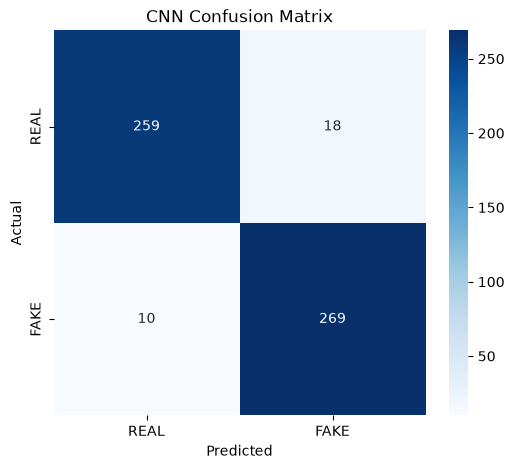

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    cnn_true,
    cnn_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

### ResNet50

**image genrator**

In [59]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

resnet_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

resnet_train_generator = resnet_train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

resnet_val_generator = resnet_test_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

resnet_test_generator = resnet_test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4445 validated image filenames belonging to 2 classes.
Found 556 validated image filenames belonging to 2 classes.
Found 556 validated image filenames belonging to 2 classes.


Load_ResNet50

In [60]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

print("ResNet50 loaded successfully")

ResNet50 loaded successfully


ResNet50 model

In [61]:
resnet_model = models.Sequential([

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [62]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [63]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
resnet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7),
    ModelCheckpoint('best_resnet_model.h5', monitor='val_loss', save_best_only=True)
]
resnet_history = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_val_generator,
    epochs=15,
    callbacks=resnet_callbacks
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9467 - loss: 0.1449 - precision: 0.9331 - recall: 0.9628

139/139 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9467 - loss: 0.1449 - precision: 0.9331 - recall: 0.9628 - val_accuracy: 0.9892 - val_loss: 0.0382 - val_precision: 0.9789 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9809 - loss: 0.0568 - precision: 0.9744 - recall: 0.9879

139/139 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9809 - loss: 0.0568 - precision: 0.9744 - recall: 0.9879 - val_accuracy: 0.9910 - val_loss: 0.0273 - val_precision: 0.9824 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9879 - loss: 0.0362 - precision: 0.9814 - recall: 0.9946

139/139 ━━━━━━━━━━━━━━━━━━━━ 352s 3s/step - accuracy: 0.9879 - loss: 0.0362 - precision: 0.9814 - recall: 0.9946 - val_accuracy: 0.9910 - val_loss: 0.0259 - val_precision: 0.9824 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9897 - loss: 0.0321 - precision: 0.9875 - recall: 0.9919

139/139 ━━━━━━━━━━━━━━━━━━━━ 383s 3s/step - accuracy: 0.9897 - loss: 0.0321 - precision: 0.9875 - recall: 0.9919 - val_accuracy: 0.9910 - val_loss: 0.0238 - val_precision: 0.9824 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9935 - loss: 0.0221 - precision: 0.9898 - recall: 0.9973

139/139 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.9935 - loss: 0.0221 - precision: 0.9898 - recall: 0.9973 - val_accuracy: 0.9910 - val_loss: 0.0222 - val_precision: 0.9824 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.9924 - loss: 0.0218 - precision: 0.9906 - recall: 0.9942 - val_accuracy: 0.9928 - val_loss: 0.0238 - val_precision: 0.9859 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 7/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9926 - loss: 0.0220 - precision: 0.9906 - recall: 0.9946

139/139 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.9926 - loss: 0.0220 - precision: 0.9906 - recall: 0.9946 - val_accuracy: 0.9946 - val_loss: 0.0203 - val_precision: 0.9894 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 8/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9939 - loss: 0.0188 - precision: 0.9924 - recall: 0.9955 - val_accuracy: 0.9928 - val_loss: 0.0208 - val_precision: 0.9859 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 9/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.9964 - loss: 0.0126 - precision: 0.9951 - recall: 0.9978 - val_accuracy: 0.9928 - val_loss: 0.0224 - val_precision: 0.9859 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 10/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9942 - loss: 0.0145 - precision: 0.9920 - recall: 0.9964 - val_accuracy: 0.9928 - val_loss: 0.0221 - val_precision: 0.9859 - val_recall: 1.0000 - learning_rate: 2.0000e-05


In [64]:
resnet_test_results = resnet_model.evaluate(
    resnet_test_generator,
    verbose=1
)

print("\nResNet50 Results")

for name, value in zip(
    resnet_model.metrics_names,
    resnet_test_results
):
    print(f"{name}: {value:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9946 - loss: 0.0144 - precision: 0.9894 - recall: 1.0000

ResNet50 Results
loss: 0.0144
compile_metrics: 0.9946


**ResNet50 Classification Report**

In [65]:
resnet_test_generator.reset()

resnet_prob = resnet_model.predict(
    resnet_test_generator
)

resnet_pred = (
    resnet_prob >= 0.5
).astype(int).flatten()

resnet_true = resnet_test_generator.classes

print(
    classification_report(
        resnet_true,
        resnet_pred,
        target_names=["REAL", "FAKE"]
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step
              precision    recall  f1-score   support

        REAL       1.00      0.99      0.99       277
        FAKE       0.99      1.00      0.99       279

    accuracy                           0.99       556
   macro avg       0.99      0.99      0.99       556
weighted avg       0.99      0.99      0.99       556



**ResNet50 Confusion Matrix**

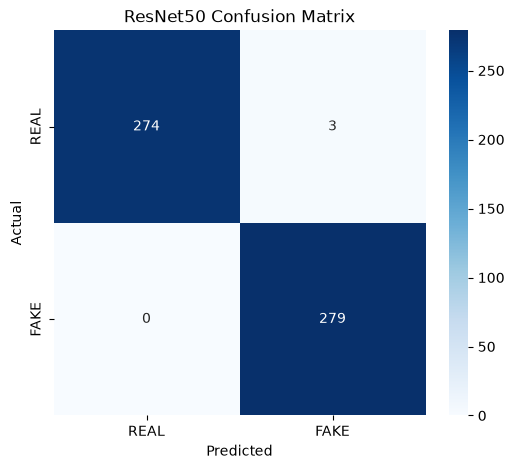

In [66]:
cm_resnet = confusion_matrix(
    resnet_true,
    resnet_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")

plt.show()

### CNN vs ResNet50 Performance Comparison & visualization

In [79]:
from sklearn.metrics import precision_score, recall_score


cnn_accuracy = accuracy_score(
    cnn_true,
    cnn_pred
)

cnn_f1 = f1_score(
    cnn_true,
    cnn_pred
)
cnn_precision = precision_score(
    cnn_true,
    cnn_pred
)
cnn_recall = recall_score(
    cnn_true,
    cnn_pred
)

resnet_accuracy = accuracy_score(
    resnet_true,
    resnet_pred
)

resnet_f1 = f1_score(
    resnet_true,
    resnet_pred
)
resnet_precision = precision_score(
    resnet_true,
    resnet_pred
)
resnet_recall = recall_score(
    resnet_true,
    resnet_pred
)


comparison = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet50"
    ],

    "Accuracy": [
        cnn_accuracy,
        resnet_accuracy,
        
    ],
    "Precision": [
        cnn_precision,
        resnet_precision
    ],
    "Recall": [
        cnn_recall,
        resnet_recall
    ],
    
    "F1 Score": [
        cnn_f1,
        resnet_f1
    ]
})

print(comparison)

        Model  Accuracy  Precision    Recall  F1 Score
0  Custom CNN  0.949640   0.937282  0.964158  0.950530
1    ResNet50  0.994604   0.989362  1.000000  0.994652


In [ ]:
comparison.to_csv(
    "cnn_vs_resnet50_comparison.csv",
    index=False
)
print("saved comparison csv successfully")

saved comparison csv successfully


**Performance comparison**

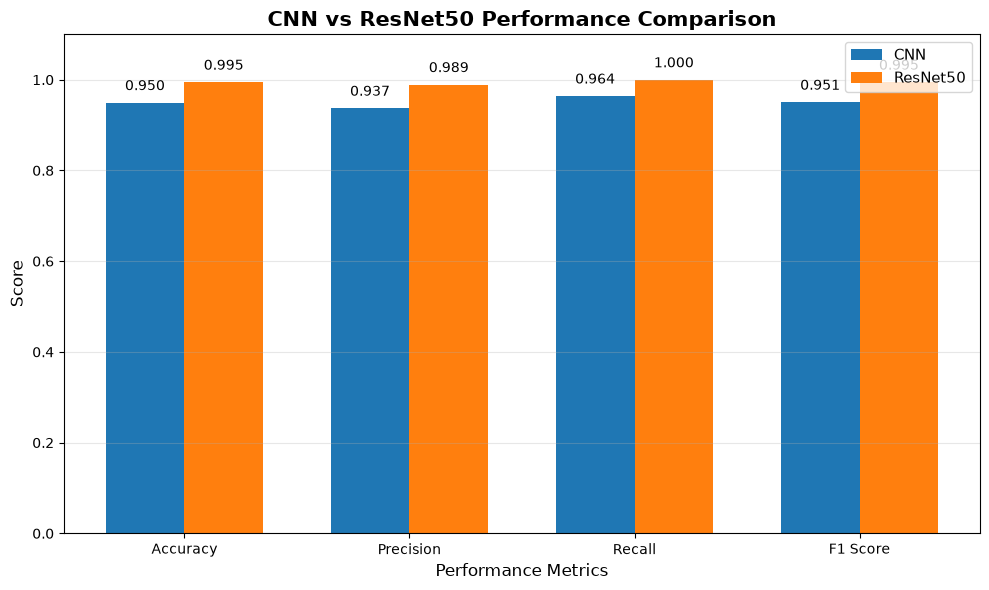

In [103]:
cnn_metrics = [
    cnn_accuracy,
    cnn_precision,
    cnn_recall,
    cnn_f1
]

resnet_metrics = [
    accuracy,
    precision,
    recall,
    f1
]

metric_names = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    cnn_metrics,
    width,
    label='CNN'
)

bars2 = plt.bar(
    x + width/2,
    resnet_metrics,
    width,
    label='ResNet50'
)

# Add values on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.xticks(x, metric_names)
plt.ylim(0, 1.1)

plt.xlabel('Performance Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)

plt.title(
    'CNN vs ResNet50 Performance Comparison',
    fontsize=15,
    fontweight='bold'
)

plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Roc Curve**

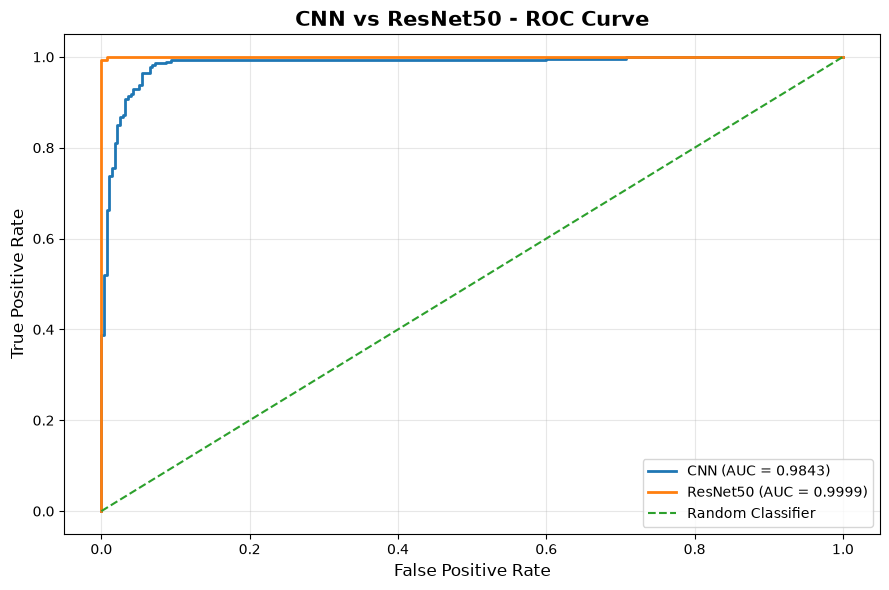

In [93]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# =========================
# CNN ROC
# =========================

cnn_fpr, cnn_tpr, _ = roc_curve(
    cnn_true,
    cnn_prob
)

cnn_auc = roc_auc_score(
    cnn_true,
    cnn_prob
)


# =========================
# ResNet50 ROC
# =========================

resnet_fpr, resnet_tpr, _ = roc_curve(
    resnet_true,
    resnet_prob
)

resnet_auc = roc_auc_score(
    resnet_true,
    resnet_prob
)


# =========================
# Plot
# =========================

plt.figure(figsize=(9, 6))

plt.plot(
    cnn_fpr,
    cnn_tpr,
    linewidth=2,
    label=f'CNN (AUC = {cnn_auc:.4f})'
)

plt.plot(
    resnet_fpr,
    resnet_tpr,
    linewidth=2,
    label=f'ResNet50 (AUC = {resnet_auc:.4f})'
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel(
    'False Positive Rate',
    fontsize=12
)

plt.ylabel(
    'True Positive Rate',
    fontsize=12
)

plt.title(
    'CNN vs ResNet50 - ROC Curve',
    fontsize=15,
    fontweight='bold'
)

plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Validation Accuracy**

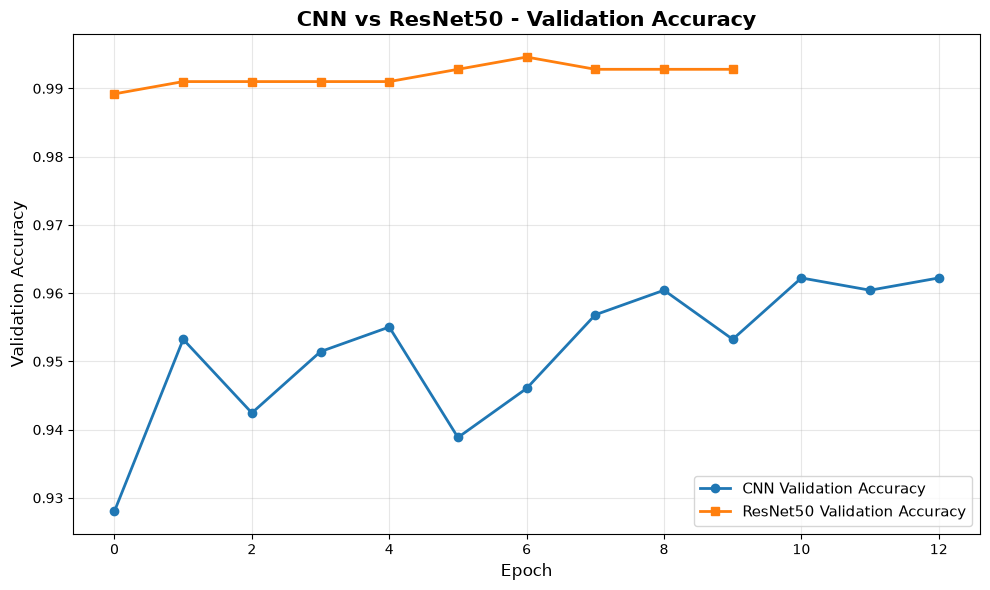

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# CNN
plt.plot(
    cnn_history.history['val_accuracy'],
    marker='o',
    linewidth=2,
    label='CNN Validation Accuracy'
)

# ResNet50
plt.plot(
    resnet_history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='ResNet50 Validation Accuracy'
)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)

plt.title(
    'CNN vs ResNet50 - Validation Accuracy',
    fontsize=15,
    fontweight='bold'
)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

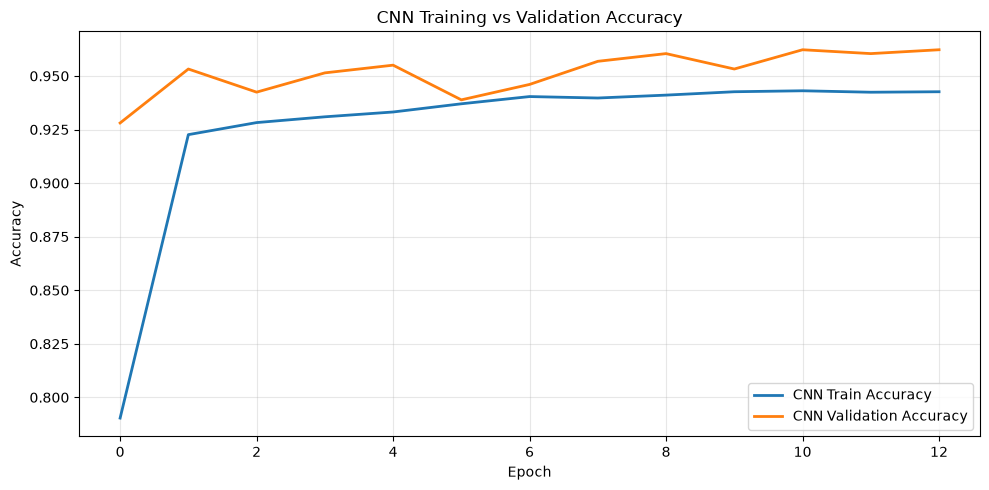

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="CNN Train Accuracy",
    linewidth=2
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="CNN Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

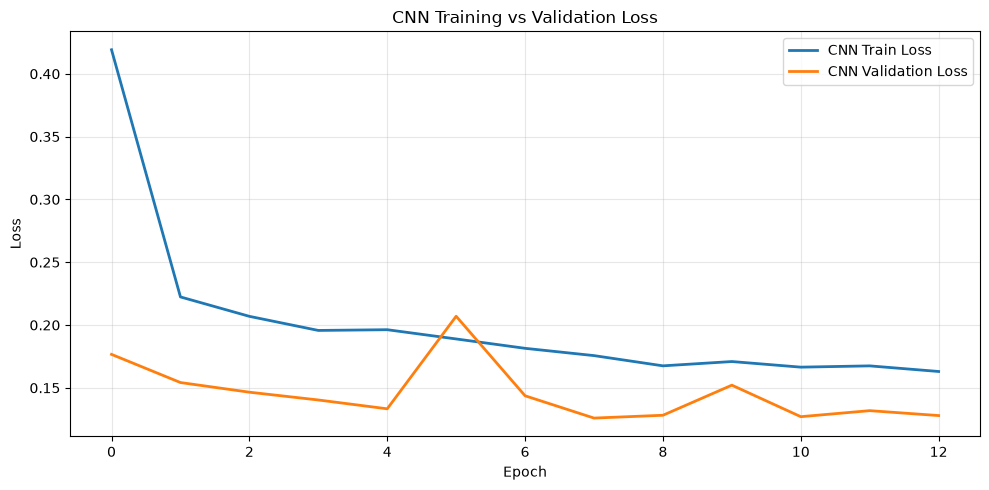

In [119]:
plt.figure(figsize=(10, 5))

plt.plot(
    cnn_history.history["loss"],
    label="CNN Train Loss",
    linewidth=2
)

plt.plot(
    cnn_history.history["val_loss"],
    label="CNN Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

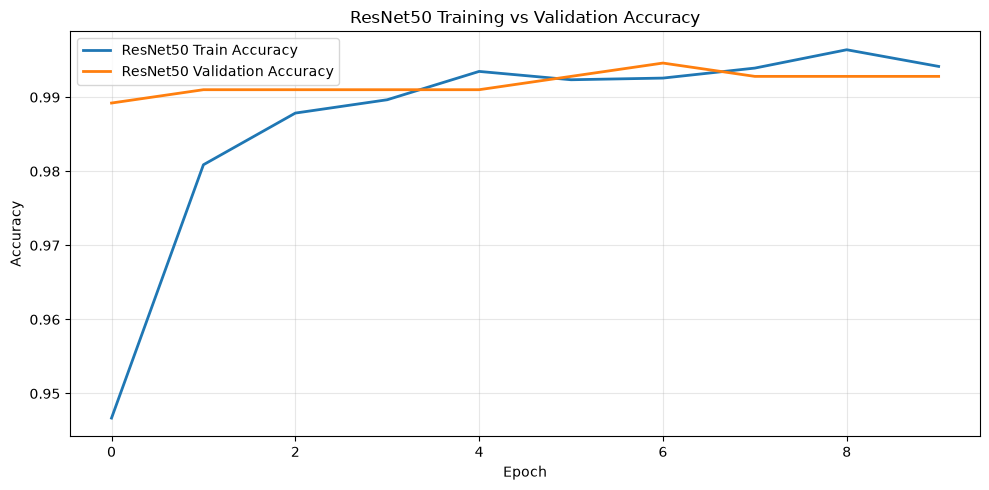

In [120]:
plt.figure(figsize=(10, 5))

plt.plot(
    resnet_history.history["accuracy"],
    label="ResNet50 Train Accuracy",
    linewidth=2
)

plt.plot(
    resnet_history.history["val_accuracy"],
    label="ResNet50 Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

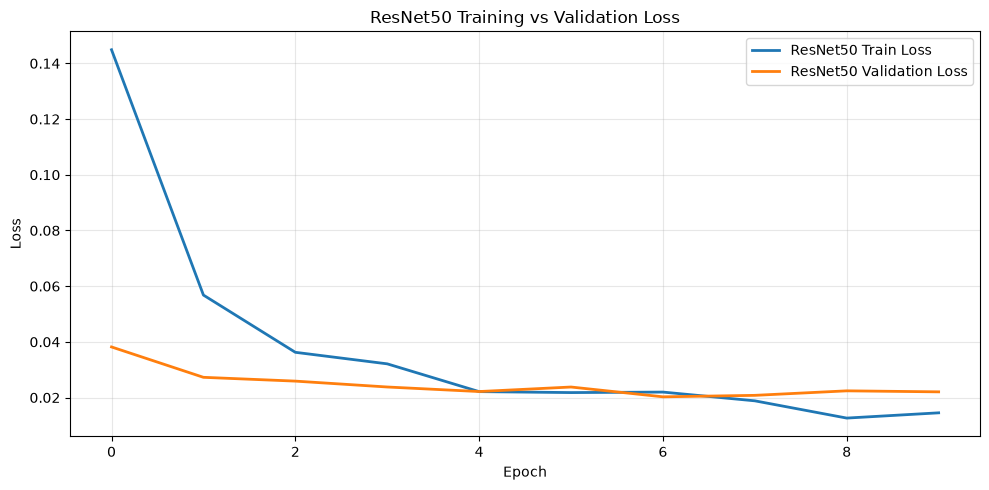

In [121]:
plt.figure(figsize=(10, 5))

plt.plot(
    resnet_history.history["loss"],
    label="ResNet50 Train Loss",
    linewidth=2
)

plt.plot(
    resnet_history.history["val_loss"],
    label="ResNet50 Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

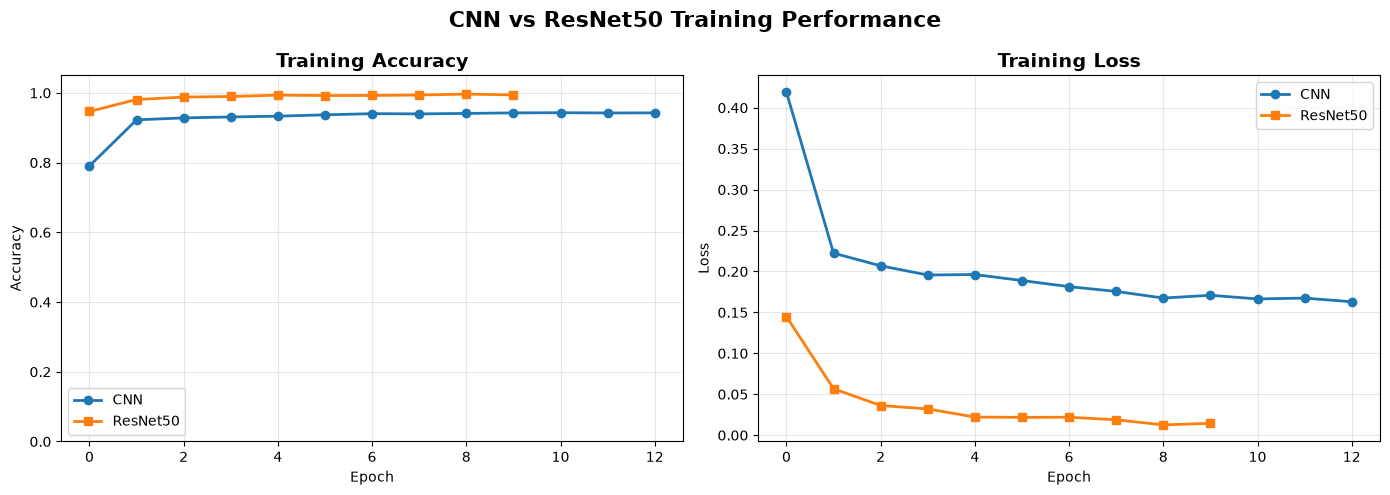

In [122]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =================================
# Training Accuracy
# =================================

axes[0].plot(
    cnn_history.history["accuracy"],
    marker="o",
    linewidth=2,
    label="CNN"
)

axes[0].plot(
    resnet_history.history["accuracy"],
    marker="s",
    linewidth=2,
    label="ResNet50"
)

axes[0].set_title(
    "Training Accuracy",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)

axes[0].legend()
axes[0].grid(alpha=0.3)


# =================================
# Training Loss
# =================================

axes[1].plot(
    cnn_history.history["loss"],
    marker="o",
    linewidth=2,
    label="CNN"
)

axes[1].plot(
    resnet_history.history["loss"],
    marker="s",
    linewidth=2,
    label="ResNet50"
)

axes[1].set_title(
    "Training Loss",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

axes[1].legend()
axes[1].grid(alpha=0.3)


# Overall title
fig.suptitle(
    "CNN vs ResNet50 Training Performance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

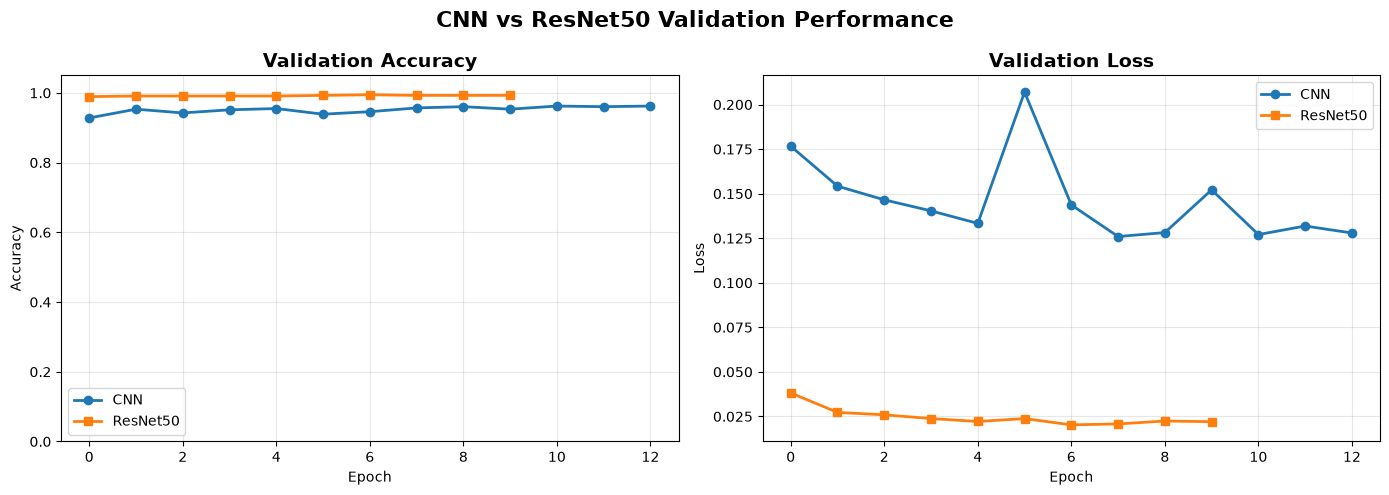

In [123]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# Validation Accuracy
# =========================

axes[0].plot(
    cnn_history.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="CNN"
)

axes[0].plot(
    resnet_history.history["val_accuracy"],
    marker="s",
    linewidth=2,
    label="ResNet50"
)

axes[0].set_title(
    "Validation Accuracy",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)


# =========================
# Validation Loss
# =========================

axes[1].plot(
    cnn_history.history["val_loss"],
    marker="o",
    linewidth=2,
    label="CNN"
)

axes[1].plot(
    resnet_history.history["val_loss"],
    marker="s",
    linewidth=2,
    label="ResNet50"
)

axes[1].set_title(
    "Validation Loss",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)


# Overall title
fig.suptitle(
    "CNN vs ResNet50 Validation Performance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Demographic analysis across gender and age

**ResNet50 Performance by Gender**

In [125]:
gender_results = []

for gender, group in test_results.groupby("gender"):

    acc = accuracy_score(
        group["y_true"],
        group["y_pred"]
    )

    f1 = f1_score(
        group["y_true"],
        group["y_pred"],
        zero_division=0
    )

    gender_results.append({
        "Gender": gender,
        "Samples": len(group),
        "Accuracy": acc,
        "F1 Score": f1
    })

gender_results = pd.DataFrame(gender_results)

print(gender_results)

    Gender  Samples  Accuracy  F1 Score
0   Female       99   1.00000  1.000000
1     Male       99   1.00000  1.000000
2  Unknown      358   0.99162  0.984127


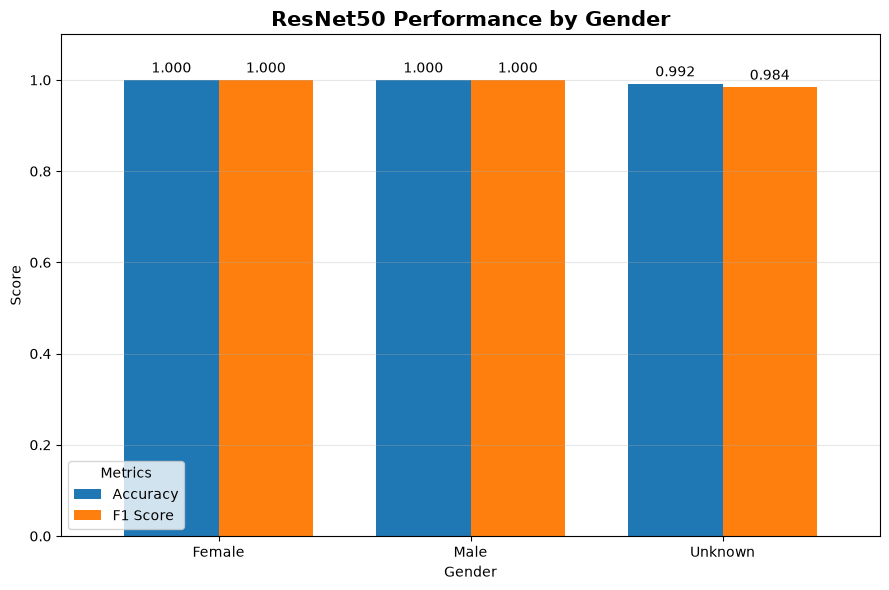

In [126]:
import matplotlib.pyplot as plt

ax = gender_results.set_index("Gender")[[
    "Accuracy",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(9, 6),
    width=0.75
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.title(
    "ResNet50 Performance by Gender",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Score")
plt.ylim(0, 1.1)

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

**ResNet50 Performance by Age Group**

In [127]:
age_results = []

for age_group, group in test_results.groupby("age_group"):

    acc = accuracy_score(
        group["y_true"],
        group["y_pred"]
    )

    f1 = f1_score(
        group["y_true"],
        group["y_pred"],
        zero_division=0
    )

    age_results.append({
        "Age Group": age_group,
        "Samples": len(group),
        "Accuracy": acc,
        "F1 Score": f1
    })

age_results = pd.DataFrame(age_results)

print(age_results)

  Age Group  Samples  Accuracy  F1 Score
0     18-25      139  1.000000  1.000000
1     26-35      133  0.992481  0.992481
2     36-50      134  1.000000  1.000000
3       50+      150  0.986667  0.986486


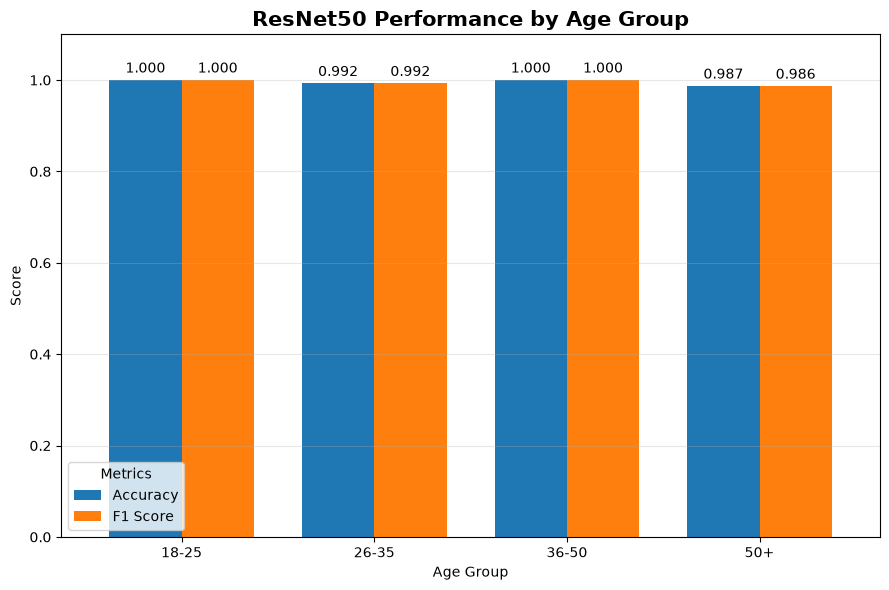

In [128]:
import matplotlib.pyplot as plt

ax = age_results.set_index("Age Group")[[
    "Accuracy",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(9, 6),
    width=0.75
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.title(
    "ResNet50 Performance by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Score")
plt.ylim(0, 1.1)

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

### Test DataFrame

In [97]:
test_results = test_df.copy()

test_results["y_true"] = resnet_true
test_results["y_pred"] = resnet_pred
test_results["y_prob"] = resnet_prob.flatten()

# Convert labels to readable names
test_results["actual_label"] = test_results["y_true"].map({
    0: "REAL",
    1: "FAKE"
})

test_results["predicted_label"] = test_results["y_pred"].map({
    0: "REAL",
    1: "FAKE"
})

print(test_results.head(5))

      image_id                                          image_url label  \
1759      1760  https://images.unsplash.com/photo-171037168337...  REAL   
5487      5488  https://api.dicebear.com/7.x/personas/jpg?seed...  FAKE   
4733      4734  https://api.dicebear.com/7.x/personas/jpg?seed...  FAKE   
201        202  https://images.unsplash.com/photo-176410564712...  REAL   
4464      4465  https://api.dicebear.com/7.x/personas/jpg?seed...  FAKE   

       gender age_group            image_path  image_exists  label_encoded  \
1759  Unknown     26-35  data/images/1760.jpg          True              0   
5487  Unknown     36-50  data/images/5488.jpg          True              1   
4733  Unknown     36-50  data/images/4734.jpg          True              1   
201   Unknown     36-50   data/images/202.jpg          True              0   
4464  Unknown       50+  data/images/4465.jpg          True              1   

      y_true  y_pred    y_prob actual_label predicted_label  
1759       1      

Test Results saving to csv file

In [98]:
test_results.to_csv(
    "resnet50_test_predictions.csv",
    index=False
)

print("CSV saved successfully!")

CSV saved successfully!


**Overall Accuracy & F1 Score**

In [96]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(
    test_results["y_true"],
    test_results["y_pred"]
)

f1 = f1_score(
    test_results["y_true"],
    test_results["y_pred"]
)

print("Overall Accuracy:", accuracy)
print("Overall F1 Score:", f1)

Overall Accuracy: 0.9946043165467626
Overall F1 Score: 0.9946524064171123


**data leakage / duplicate images / near-duplicate images**

In [101]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print(
    "Duplicate image paths:",
    df["image_path"].duplicated().sum()
)

Train: 4445
Validation: 556
Test: 556
Duplicate image paths: 0


In [102]:
print(
    "Train-Test overlap:",
    len(set(train_df["image_id"]) &
        set(test_df["image_id"]))
)

print(
    "Train-Val overlap:",
    len(set(train_df["image_id"]) &
        set(val_df["image_id"]))
)

print(
    "Val-Test overlap:",
    len(set(val_df["image_id"]) &
        set(test_df["image_id"]))
)

Train-Test overlap: 0
Train-Val overlap: 0
Val-Test overlap: 0


### Project Summary

A deep learning-based REAL vs FAKE image classification system was developed
using CNN and ResNet50. Both models were trained and evaluated using
Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC.

The comparison demonstrated that ResNet50 provided stronger classification
performance than the custom CNN. Demographic analysis across gender and age
groups was also performed to assess model consistency.

Overall, the project successfully demonstrates the use of deep learning and
transfer learning for deepfake detection, from data preprocessing and model
training to performance evaluation and demographic analysis.

-------------